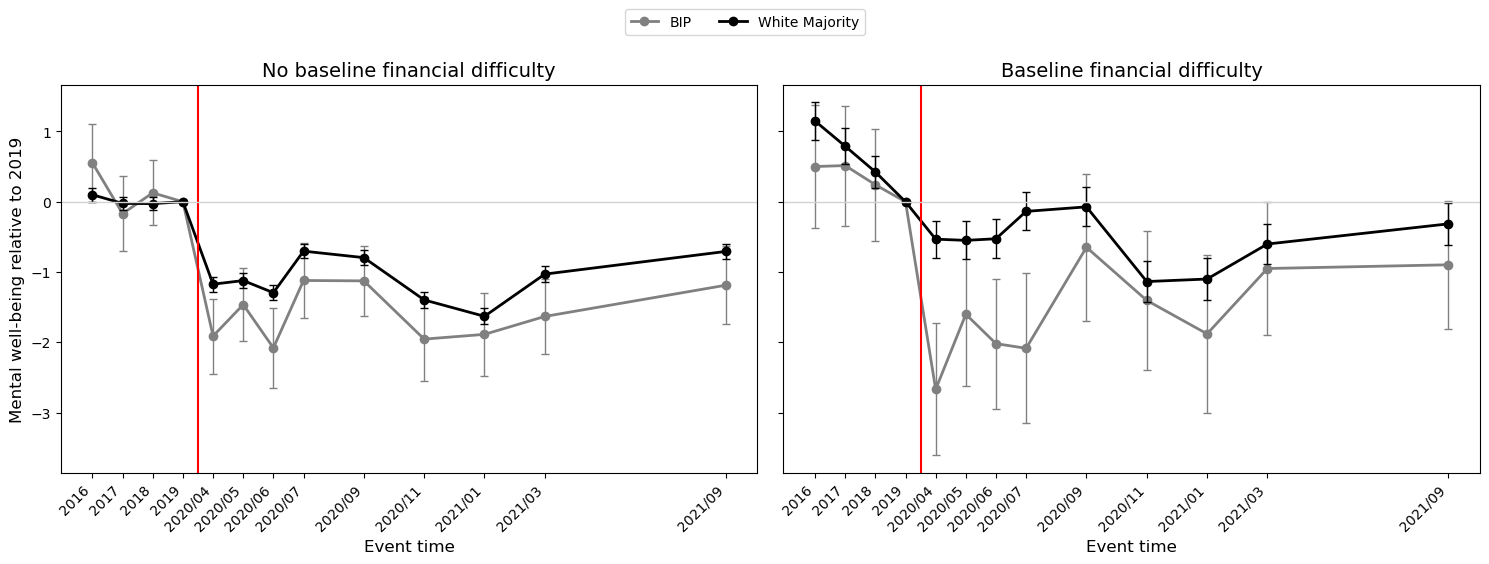

Saved combined figure to: /Users/lishixue/Documents/Master thesis/Statafile/Thesis2026/out/Event study/ESBIPbyfin/esbip_byfindiff_event_study_combined.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===== paths =====
work = Path("/Users/lishixue/Documents/Master thesis/Statafile/work/ESBIPbyfin")
out = Path("/Users/lishixue/Documents/Master thesis/Statafile/Thesis2026/out/Event study/ESBIPbyfin")
out.mkdir(parents=True, exist_ok=True)

# ===== event-time mapping =====
event_map = {
    1: -4,   # 2016
    2: -3,   # 2017
    3: -2,   # 2018
    4: -1,   # 2019 baseline
    5: 0,    # 2020/04
    6: 1,    # 2020/05
    7: 2,    # 2020/06
    8: 3,    # 2020/07
    9: 5,    # 2020/09
    10: 7,   # 2020/11
    11: 9,   # 2021/01
    12: 11,  # 2021/03
    13: 17   # 2021/09
}

event_labels = [
    "2016", "2017", "2018", "2019", "2020/04", "2020/05", "2020/06",
    "2020/07", "2020/09", "2020/11", "2021/01", "2021/03", "2021/09"
]


def prepare_data(fname):
    infile = work / f"esbip_{fname}_plotdata.csv"
    df = pd.read_csv(infile)

    # Make column names compatible with either version of Stata output
    rename_map = {
        "est_wm": "est_nonbip",
        "se_wm": "se_nonbip",
        "lb_wm": "lb_nonbip",
        "ub_wm": "ub_nonbip",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    df["event_time"] = df["evt"].map(event_map)
    df = df.sort_values("event_time")

    return df


def plot_on_axis(ax, df, title, show_ylabel=False):
    # BIP
    ax.plot(
        df["event_time"], df["est_bip"],
        color="gray", marker="o", linewidth=2, label="BIP"
    )
    ax.errorbar(
        df["event_time"], df["est_bip"],
        yerr=[
            df["est_bip"] - df["lb_bip"],
            df["ub_bip"] - df["est_bip"]
        ],
        fmt="none", color="gray", capsize=3, linewidth=1
    )

    # White majority
    ax.plot(
        df["event_time"], df["est_nonbip"],
        color="black", marker="o", linewidth=2, label="White Majority"
    )
    ax.errorbar(
        df["event_time"], df["est_nonbip"],
        yerr=[
            df["est_nonbip"] - df["lb_nonbip"],
            df["ub_nonbip"] - df["est_nonbip"]
        ],
        fmt="none", color="black", capsize=3, linewidth=1
    )

    # Pandemic onset line
    ax.axvline(x=-0.5, color="red", linewidth=1.5)

    # 2019 baseline
    ax.axhline(y=0, color="lightgray", linewidth=1)

    ax.set_xticks(df["event_time"])
    ax.set_xticklabels(event_labels, rotation=45, ha="right")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Event time", fontsize=12)

    if show_ylabel:
        ax.set_ylabel("Mental well-being relative to 2019", fontsize=12)


# ===== Read data =====
df_nofindiff = prepare_data("nofindiff")
df_findiff = prepare_data("findiff")

# ===== Combined figure: left no difficulty, right difficulty =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

plot_on_axis(axes[0], df_nofindiff, "No baseline financial difficulty", show_ylabel=True)
plot_on_axis(axes[1], df_findiff, "Baseline financial difficulty", show_ylabel=False)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.03)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

outfile = out / "esbip_byfindiff_event_study_combined.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved combined figure to: {outfile}")

In [2]:
import pandas as pd
from pathlib import Path

# ===== paths =====
out = Path("/Users/lishixue/Documents/Master thesis/Statafile/Thesis2026/out/Event study/ESBIPbyfin")

nofindiff_file = out / "ESbip_nofindiff_theta_table.csv"
findiff_file = out / "ESbip_findiff_theta_table.csv"
outfile = out / "ESbip_byfindiff_theta_table.tex"


def clean_theta_table(path, group_label):
    df = pd.read_csv(path)

    if "stars" in df.columns:
        df["stars"] = df["stars"].fillna("")
    else:
        df["stars"] = ""

    if "theta" not in df.columns:
        raise ValueError(f"Cannot find theta in {path}")

    if "pval" not in df.columns:
        raise ValueError(f"Cannot find pval in {path}")

    df["coef"] = df.apply(
        lambda row: "" if pd.isna(row["theta"]) else f"{row['theta']:.2f}{row['stars']}",
        axis=1
    )

    df["p"] = df["pval"].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")

    df = df[["period", "coef", "p"]].copy()
    df.columns = ["Period", f"{group_label} coefficient", f"{group_label} p-value"]

    return df


nofindiff = clean_theta_table(nofindiff_file, "No difficulty")
findiff = clean_theta_table(findiff_file, "Difficulty")

table_df = nofindiff.merge(findiff, on="Period", how="outer")

# Keep intended order
period_order = [
    "2019 (base)", "2016", "2017", "2018",
    "2020/04", "2020/05", "2020/06", "2020/07",
    "2020/09", "2020/11", "2021/01", "2021/03", "2021/09",
    "Joint pre-trend"
]

table_df["order"] = table_df["Period"].apply(
    lambda x: period_order.index(x) if x in period_order else 999
)
table_df = table_df.sort_values("order").drop(columns="order")

# ===== LaTeX tabular =====
tabular = table_df.to_latex(
    index=False,
    escape=False,
    column_format="lcccc"
)

latex_table = rf"""
\begin{{table}}[htbp]
\centering
\caption{{Event-study estimates of the BIP--White majority gap in mental well-being by baseline financial difficulty}}
\label{{tab:event_study_bip_byfindiff}}
\small
{tabular}
\begin{{flushleft}}
\footnotesize
Notes: The table reports event-study interaction coefficients for the BIP--White majority gap in mental well-being, estimated separately by baseline financial difficulty. The ``No difficulty'' columns compare BIP respondents with White-majority respondents among individuals who did not report financial difficulty in 2019, while the ``Difficulty'' columns compare BIP respondents with White-majority respondents among individuals who reported baseline financial difficulty in 2019. The 2019 calendar year is omitted as the baseline period. The outcome is the April-adjusted and inverted GHQ-12 Likert score, so higher values indicate better mental well-being. A negative coefficient indicates that BIP respondents experienced a relative deterioration in mental well-being compared with the White majority within the same baseline financial-difficulty group. Standard errors are clustered at the individual level. *, **, and *** denote significance at the 10\%, 5\%, and 1\% levels, respectively. The row ``Joint pre-trend'' reports the p-value from the joint test of whether all pre-pandemic interaction coefficients are equal to zero.
\end{{flushleft}}
\end{{table}}
""".strip()

with open(outfile, "w", encoding="utf-8") as f:
    f.write(latex_table)

print(latex_table)
print(f"\nSaved to: {outfile}")

\begin{table}[htbp]
\centering
\caption{Event-study estimates of the BIP--White majority gap in mental well-being by baseline financial difficulty}
\label{tab:event_study_bip_byfindiff}
\small
\begin{tabular}{lcccc}
\toprule
Period & No difficulty coefficient & No difficulty p-value & Difficulty coefficient & Difficulty p-value \\
\midrule
2019 (base) & 0.00 &  & 0.00 &  \\
2016 & 0.45 & 0.11 & -0.65 & 0.16 \\
2017 & -0.15 & 0.60 & -0.28 & 0.54 \\
2018 & 0.15 & 0.52 & -0.18 & 0.67 \\
2020/04 & -0.74*** & 0.01 & -2.14*** & 0.00 \\
2020/05 & -0.34 & 0.21 & -1.05* & 0.05 \\
2020/06 & -0.79*** & 0.01 & -1.49*** & 0.00 \\
2020/07 & -0.42 & 0.13 & -1.95*** & 0.00 \\
2020/09 & -0.33 & 0.21 & -0.58 & 0.30 \\
2020/11 & -0.56* & 0.07 & -0.27 & 0.61 \\
2021/01 & -0.26 & 0.41 & -0.78 & 0.19 \\
2021/03 & -0.60** & 0.03 & -0.35 & 0.49 \\
2021/09 & -0.48* & 0.10 & -0.58 & 0.23 \\
Joint pre-trend &  & 0.18 &  & 0.58 \\
\bottomrule
\end{tabular}

\begin{flushleft}
\footnotesize
Notes: The table reports